# HR Database — Data Profiling & Regression Analysis

**Tables:** employees, departments, dept_emp, dept_manager, salaries, titles  
**Workflow:**
1. Load CSVs → SQLite `.db`
2. Profile each table
3. Build an analysis-ready flat table
4. Regression: salary ~ tenure, gender, department, title

## 0. Setup

In [1]:
# !pip install pandas statsmodels matplotlib seaborn

In [2]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from pathlib import Path

DATA_DIR   = Path('.')
DB_PATH    = DATA_DIR / 'hr.db'
OUTPUT_DIR = Path('..') / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

pd.set_option('display.float_format', '{:,.2f}'.format)
sns.set_theme(style='whitegrid')
print('Setup complete')
print(f'Outputs → {OUTPUT_DIR.resolve()}')

Setup complete
Outputs → /home/runner/work/HR-ETL-Analysis/HR-ETL-Analysis/outputs


## 1. Load CSVs → SQLite

In [3]:
TABLES = ['employees', 'departments', 'dept_emp', 'dept_manager', 'salaries', 'titles']

conn = sqlite3.connect(DB_PATH)

for table in TABLES:
    df = pd.read_csv(DATA_DIR / f'{table}.csv')
    df.to_sql(table, conn, if_exists='replace', index=False)
    print(f'  {table:15s}  {len(df):>10,} rows  {list(df.columns)}')

print(f'\nDatabase saved → {DB_PATH.resolve()}')

  employees           300,024 rows  ['emp_no', 'birth_date', 'first_name', 'last_name', 'gender', 'hire_date']
  departments               9 rows  ['dept_no', 'dept_name']


  dept_emp            157,368 rows  ['emp_no', 'dept_no', 'from_date', 'to_date']
  dept_manager             24 rows  ['emp_no', 'dept_no', 'from_date', 'to_date']
  salaries             78,468 rows  ['emp_no', 'salary', 'from_date', 'to_date']


  titles               49,432 rows  ['emp_no', 'title', 'from_date', 'to_date']

Database saved → /home/runner/work/HR-ETL-Analysis/HR-ETL-Analysis/dataset/hr.db


## 2. Data Profiling

In [4]:
profile_frames = {}

def profile_table(name: str) -> pd.DataFrame:
    df = pd.read_sql(f'SELECT * FROM {name}', conn)
    stats = pd.DataFrame({
        'dtype':    df.dtypes,
        'nulls':    df.isna().sum(),
        'null_pct': (df.isna().mean() * 100).round(2),
        'unique':   df.nunique(),
        'sample':   [df[c].dropna().iloc[0] if df[c].notna().any() else None for c in df.columns],
    })
    print(f'\n── {name.upper()} ── {len(df):,} rows × {len(df.columns)} cols')
    display(stats)
    profile_frames[name] = stats
    return df

raw = {t: profile_table(t) for t in TABLES}

# Save profiling stats per table
for name, stats in profile_frames.items():
    stats.to_csv(OUTPUT_DIR / f'profile_{name}.csv')
print('\nProfiling CSVs saved to outputs/')


── EMPLOYEES ── 300,024 rows × 6 cols


,dtype,nulls,null_pct,unique,sample
emp_no,int64,0,0.00,300024,10001
birth_date,str,0,0.00,4750,1953-09-02
first_name,str,0,0.00,1275,Georgi
last_name,str,0,0.00,1637,Facello
gender,str,0,0.00,2,M
hire_date,str,0,0.00,5434,1986-06-26



── DEPARTMENTS ── 9 rows × 2 cols


,dtype,nulls,null_pct,unique,sample
dept_no,str,0,0.00,9,d009
dept_name,str,0,0.00,9,Customer Service



── DEPT_EMP ── 157,368 rows × 4 cols


...


── SALARIES ── 78,468 rows × 4 cols


,dtype,nulls,null_pct,unique,sample
emp_no,int64,0,0.00,8255,10001
salary,int64,0,0.00,42203,60117
from_date,str,0,0.00,6262,1986-06-26
to_date,str,0,0.00,5907,1987-06-26



── TITLES ── 49,432 rows × 4 cols


,dtype,nulls,null_pct,unique,sample
emp_no,int64,0,0.00,33458,10001
title,str,1,0.00,6,Senior Engineer
from_date,str,1,0.00,6367,1986-06-26
to_date,str,1,0.00,4725,9999-01-01



Profiling CSVs saved to outputs/


In [5]:
# Date range check
date_ranges = []
for t in ['employees', 'salaries', 'titles', 'dept_emp']:
    df = raw[t]
    date_cols = [c for c in df.columns if 'date' in c]
    print(f'\n{t}')
    for c in date_cols:
        s = pd.to_datetime(df[c], errors='coerce')
        row = {'table': t, 'column': c, 'min': s.min().date(), 'max': s.max().date(), 'unparseable': s.isna().sum()}
        date_ranges.append(row)
        print(f'  {c}: {row["min"]} → {row["max"]}  ({row["unparseable"]} unparseable)')

pd.DataFrame(date_ranges).to_csv(OUTPUT_DIR / 'profile_date_ranges.csv', index=False)
print('\nDate ranges saved → outputs/profile_date_ranges.csv')


employees
  birth_date: 1952-02-01 → 1965-02-01  (0 unparseable)
  hire_date: 1985-01-01 → 2000-01-28  (0 unparseable)

salaries


  from_date: 1985-02-02 → 2002-08-01  (0 unparseable)
  to_date: 1985-08-08 → 9999-01-01  (1 unparseable)

titles
  from_date: 1985-02-02 → 2002-08-01  (1 unparseable)
  to_date: 1985-03-01 → 9999-01-01  (1 unparseable)

dept_emp
  from_date: 1985-01-01 → 2002-08-01  (0 unparseable)
  to_date: 1985-02-17 → 9999-01-01  (1 unparseable)

Date ranges saved → outputs/profile_date_ranges.csv


count    78,468.00
mean     64,069.79
std      17,062.54
min      38,812.00
25%      50,583.00
50%      61,417.50
75%      74,612.25
max     145,732.00
Name: salary_all_records, dtype: float64


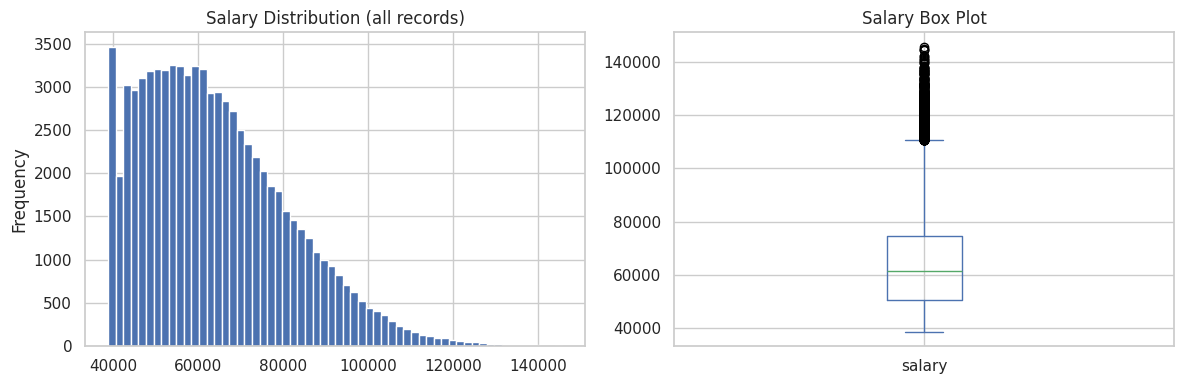

Saved → outputs/chart_salary_distribution.png


In [6]:
# Salary distribution
sal = raw['salaries'].copy()
salary_desc = sal['salary'].describe().rename('salary_all_records')
print(salary_desc)
salary_desc.to_csv(OUTPUT_DIR / 'profile_salary_distribution.csv', header=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sal['salary'].plot.hist(bins=60, ax=axes[0], title='Salary Distribution (all records)')
sal['salary'].plot.box(ax=axes[1], title='Salary Box Plot')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'chart_salary_distribution.png', dpi=150)
plt.show()
print('Saved → outputs/chart_salary_distribution.png')

gender
M    179973
F    120051
Name: count, dtype: int64


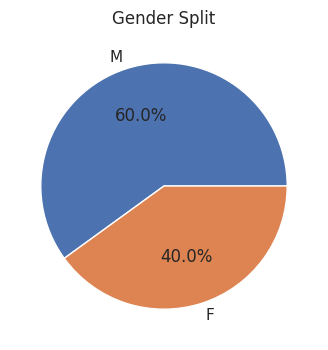

Saved → outputs/chart_gender_split.png


In [7]:
# Gender split
gender_counts = raw['employees']['gender'].value_counts()
print(gender_counts)
gender_counts.to_csv(OUTPUT_DIR / 'profile_gender_split.csv', header=True)

gender_counts.plot.pie(autopct='%1.1f%%', figsize=(4, 4), title='Gender Split')
plt.ylabel('')
plt.savefig(OUTPUT_DIR / 'chart_gender_split.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → outputs/chart_gender_split.png')

title
Engineer              12929
Staff                 11912
Senior Engineer       10963
Senior Staff          10222
Technique Leader       1724
Assistant Engineer     1681
Name: count, dtype: int64


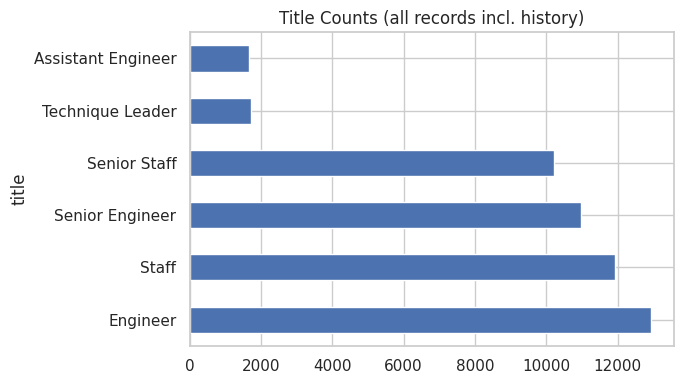

Saved → outputs/chart_title_counts.png


In [8]:
# Title distribution
title_counts = raw['titles']['title'].value_counts()
print(title_counts)
title_counts.to_csv(OUTPUT_DIR / 'profile_title_counts.csv', header=True)

title_counts.plot.barh(figsize=(7, 4), title='Title Counts (all records incl. history)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'chart_title_counts.png', dpi=150)
plt.show()
print('Saved → outputs/chart_title_counts.png')

## 3. Build Analysis Table

One row per employee using **current** (most recent) salary, title, and department.

In [9]:
query = """
WITH current_salary AS (
    SELECT emp_no, salary
    FROM salaries
    WHERE to_date = '9999-01-01'
),
current_title AS (
    SELECT emp_no, title
    FROM titles
    WHERE to_date = '9999-01-01'
),
current_dept AS (
    SELECT de.emp_no, de.dept_no, d.dept_name
    FROM dept_emp de
    JOIN departments d ON d.dept_no = de.dept_no
    WHERE de.to_date = '9999-01-01'
)
SELECT
    e.emp_no,
    e.gender,
    e.birth_date,
    e.hire_date,
    cd.dept_name,
    ct.title,
    cs.salary
FROM employees e
JOIN current_salary  cs ON cs.emp_no = e.emp_no
JOIN current_title   ct ON ct.emp_no = e.emp_no
JOIN current_dept    cd ON cd.emp_no = e.emp_no
"""

analysis = pd.read_sql(query, conn)
print(f'{len(analysis):,} active employees loaded')
analysis.head()

6,652 active employees loaded


,emp_no,gender,birth_date,hire_date,dept_name,title,salary
0,10001,M,1953-09-02,1986-06-26,Development,Senior Engineer,88958
1,10002,F,1964-06-02,1985-11-21,Sales,Staff,72527
2,10003,M,1959-12-03,1986-08-28,Production,Senior Engineer,43311
3,10004,M,1954-05-01,1986-12-01,Production,Senior Engineer,74057
4,10005,M,1955-01-21,1989-09-12,Human Resources,Senior Staff,94692


In [10]:
ref_date = pd.Timestamp('2002-08-01')

analysis['birth_date'] = pd.to_datetime(analysis['birth_date'])
analysis['hire_date']  = pd.to_datetime(analysis['hire_date'])

analysis['age_at_hire']   = ((analysis['hire_date'] - analysis['birth_date']).dt.days / 365.25).round(1)
analysis['tenure_years']  = ((ref_date - analysis['hire_date']).dt.days / 365.25).round(2)
analysis['gender_binary'] = (analysis['gender'] == 'M').astype(int)

desc = analysis[['salary', 'tenure_years', 'age_at_hire']].describe()
print(desc)
desc.to_csv(OUTPUT_DIR / 'profile_analysis_flat_summary.csv')
print('Saved → outputs/profile_analysis_flat_summary.csv')

          salary  tenure_years  age_at_hire
count   6,652.00      6,652.00     6,652.00
mean   72,076.09         12.46        31.56
std    17,477.80          3.50         5.16
min    39,012.00          2.58        20.10
25%    58,887.25          9.97        27.70
50%    69,829.50         13.03        31.40
75%    82,854.00         15.39        35.10
max   145,732.00         17.49        47.60
Saved → outputs/profile_analysis_flat_summary.csv


## 4. Exploratory Salary Analysis

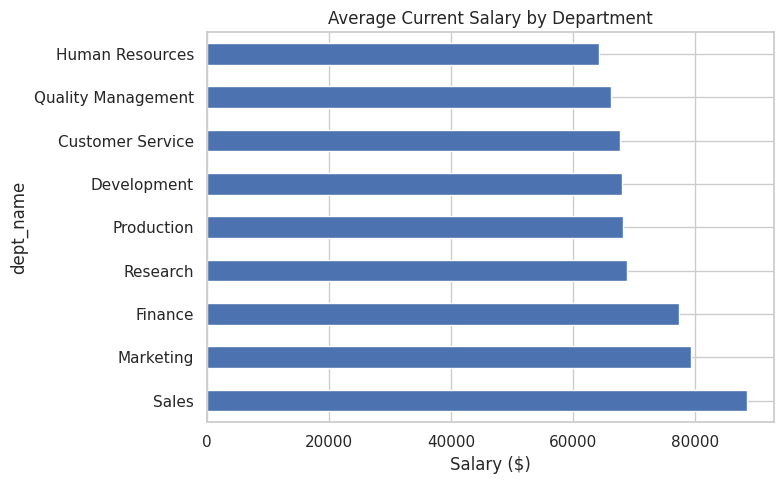

Saved → outputs/chart_salary_by_department.png


In [11]:
# Avg salary by department
dept_sal = analysis.groupby('dept_name')['salary'].mean().sort_values(ascending=False)
dept_sal.to_csv(OUTPUT_DIR / 'eda_salary_by_department.csv', header=True)

dept_sal.plot.barh(figsize=(8, 5), title='Average Current Salary by Department')
plt.xlabel('Salary ($)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'chart_salary_by_department.png', dpi=150)
plt.show()
print('Saved → outputs/chart_salary_by_department.png')

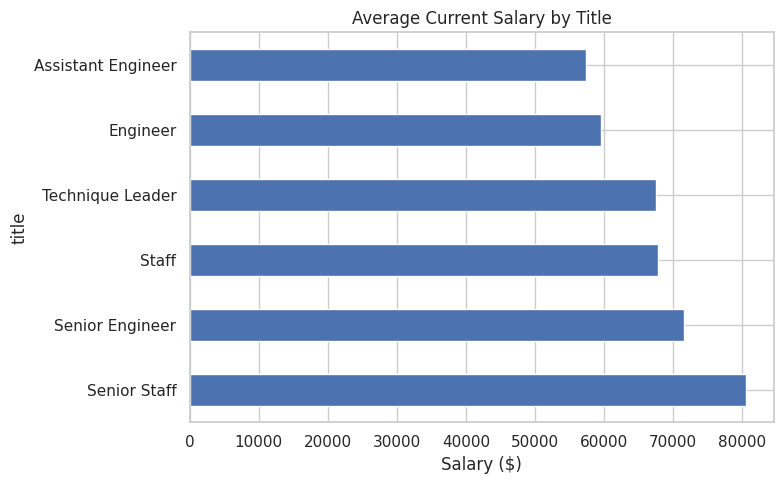

Saved → outputs/chart_salary_by_title.png


In [12]:
# Avg salary by title
title_sal = analysis.groupby('title')['salary'].mean().sort_values(ascending=False)
title_sal.to_csv(OUTPUT_DIR / 'eda_salary_by_title.csv', header=True)

title_sal.plot.barh(figsize=(8, 5), title='Average Current Salary by Title')
plt.xlabel('Salary ($)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'chart_salary_by_title.png', dpi=150)
plt.show()
print('Saved → outputs/chart_salary_by_title.png')

In [13]:
# Salary by gender
gender_sal = analysis.groupby('gender')['salary'].describe()
print(gender_sal)
gender_sal.to_csv(OUTPUT_DIR / 'eda_salary_by_gender.csv')
print('Saved → outputs/eda_salary_by_gender.csv')

          count      mean       std       min       25%       50%       75%  \
gender                                                                        
F      2,676.00 72,244.25 17,327.36 40,817.00 59,291.00 70,067.50 82,854.00   
M      3,976.00 71,962.91 17,579.59 39,012.00 58,597.25 69,695.00 82,843.75   

              max  
gender             
F      144,866.00  
M      145,732.00  
Saved → outputs/eda_salary_by_gender.csv


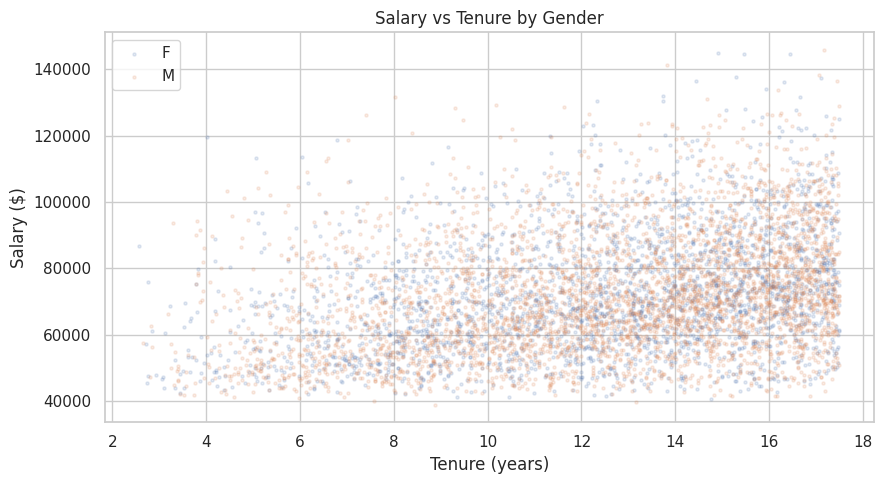

Saved → outputs/chart_salary_vs_tenure.png


In [14]:
# Salary vs tenure scatter
fig, ax = plt.subplots(figsize=(9, 5))
for g, grp in analysis.groupby('gender'):
    ax.scatter(grp['tenure_years'], grp['salary'], alpha=0.15, s=5, label=g)
ax.set_xlabel('Tenure (years)')
ax.set_ylabel('Salary ($)')
ax.set_title('Salary vs Tenure by Gender')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'chart_salary_vs_tenure.png', dpi=150)
plt.show()
print('Saved → outputs/chart_salary_vs_tenure.png')

## 5. Regression: Salary ~ Tenure + Gender + Department + Title

In [15]:
model = smf.ols(
    'salary ~ tenure_years + age_at_hire + gender_binary + C(dept_name) + C(title)',
    data=analysis
).fit()

print(model.summary())

# Save full summary as text
with open(OUTPUT_DIR / 'regression_summary.txt', 'w') as f:
    f.write(model.summary().as_text())
print('Saved → outputs/regression_summary.txt')

                            OLS Regression Results                            
Dep. Variable:                 salary   R-squared:                       0.354
Model:                            OLS   Adj. R-squared:                  0.352
Method:                 Least Squares   F-statistic:                     227.2
Date:                Tue, 02 Jun 2026   Prob (F-statistic):               0.00
Time:                        02:01:54   Log-Likelihood:                -72966.
No. Observations:                6652   AIC:                         1.460e+05
Df Residuals:                    6635   BIC:                         1.461e+05
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Inte

In [16]:
# Coefficients table
coef = pd.DataFrame({
    'coef':    model.params,
    'std_err': model.bse,
    't':       model.tvalues,
    'p_value': model.pvalues,
    'ci_low':  model.conf_int()[0],
    'ci_high': model.conf_int()[1],
}).reset_index().rename(columns={'index': 'predictor'})
coef['significant'] = coef['p_value'] < 0.05
coef['abs_coef'] = coef['coef'].abs()
coef = coef.sort_values('abs_coef', ascending=False)

display(coef)
coef.to_csv(OUTPUT_DIR / 'regression_coefficients.csv', index=False)
print('Saved → outputs/regression_coefficients.csv')

,predictor,coef,std_err,t,p_value,ci_low,ci_high,significant,abs_coef
0,Intercept,"47,790.53","2,691.43",17.76,0.00,"42,514.46","53,066.61",True,"47,790.53"
8,C(dept_name)[T.Sales],"21,520.25",787.01,27.34,0.00,"19,977.45","23,063.05",True,"21,520.25"
4,C(dept_name)[T.Marketing],"12,602.39",968.83,13.01,0.00,"10,703.17","14,501.62",True,"12,602.39"
2,C(dept_name)[T.Finance],"10,350.10","1,003.77",10.31,0.00,"8,382.39","12,317.80",True,"10,350.10"
10,C(title)[T.Senior Engineer],"10,242.91","1,401.68",7.31,0.00,"7,495.17","12,990.64",True,"10,242.91"
11,C(title)[T.Senior Staff],"9,653.27","1,668.57",5.79,0.00,"6,382.34","12,924.20",True,"9,653.27"
13,C(title)[T.Technique Leader],"7,437.43","1,549.31",4.80,0.00,"4,400.29","10,474.57",True,"7,437.43"
3,C(dept_name)[T.Human Resources],"-2,819.62",977.92,-2.88,0.00,"-4,736.66",-902.59,True,"2,819.62"
14,tenure_years,"1,131.98",70.55,16.04,0.00,993.67,"1,270.29",True,"1,131.98"
9,C(title)[T.Engineer],"1,059.31","1,441.67",0.73,0.46,"-1,766.82","3,885.45",False,"1,059.31"


Saved → outputs/regression_coefficients.csv


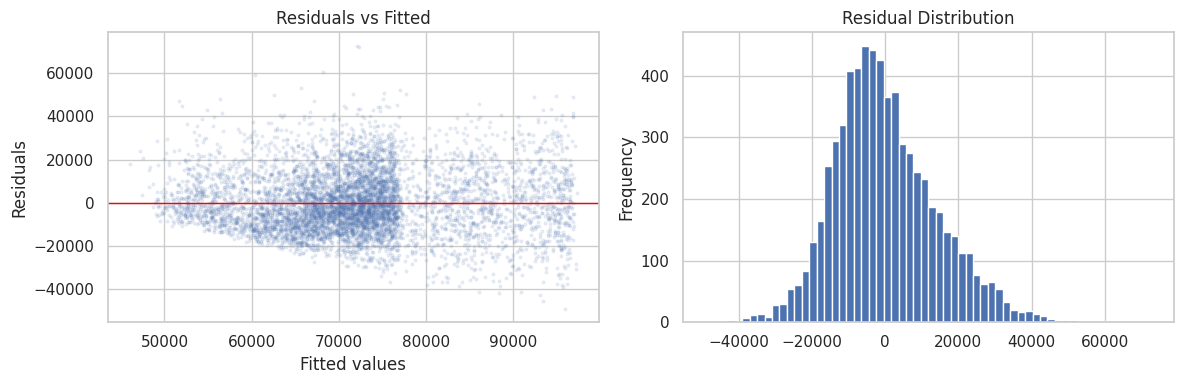

r_squared             0.35
adj_r_squared         0.35
f_statistic         227.20
n_obs             6,652.00
aic             145,966.99
bic             146,082.63
Name: value, dtype: float64
Saved → outputs/chart_regression_residuals.png
Saved → outputs/regression_model_metrics.csv


In [17]:
# Residual plots
fitted    = model.fittedvalues
residuals = model.resid

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(fitted, residuals, alpha=0.1, s=4)
axes[0].axhline(0, color='red', lw=1)
axes[0].set_xlabel('Fitted values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted')
pd.Series(residuals).plot.hist(bins=60, ax=axes[1], title='Residual Distribution')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'chart_regression_residuals.png', dpi=150)
plt.show()

# Model fit metrics
metrics = pd.Series({
    'r_squared':     round(model.rsquared, 4),
    'adj_r_squared': round(model.rsquared_adj, 4),
    'f_statistic':   round(model.fvalue, 2),
    'n_obs':         int(model.nobs),
    'aic':           round(model.aic, 2),
    'bic':           round(model.bic, 2),
}, name='value')
print(metrics)
metrics.to_csv(OUTPUT_DIR / 'regression_model_metrics.csv', header=True)
print('Saved → outputs/chart_regression_residuals.png')
print('Saved → outputs/regression_model_metrics.csv')

## 6. Save Analysis Table Back to SQLite

In [18]:
analysis.to_sql('analysis_flat', conn, if_exists='replace', index=False)
print('Saved analysis_flat table to hr.db')

tables_in_db = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print(tables_in_db)

Saved analysis_flat table to hr.db
            name
0      employees
1    departments
2       dept_emp
3   dept_manager
4       salaries
5         titles
6  analysis_flat


In [19]:
conn.close()
print('Connection closed. hr.db is ready for SQL queries.')

print('\nAll outputs saved:')
for f in sorted(OUTPUT_DIR.iterdir()):
    print(f'  {f.name}')

Connection closed. hr.db is ready for SQL queries.

All outputs saved:
  chart_gender_split.png
  chart_regression_residuals.png
  chart_salary_by_department.png
  chart_salary_by_title.png
  chart_salary_distribution.png
  chart_salary_vs_tenure.png
  chart_title_counts.png
  db_indexes.txt
  db_integrity_check.txt
  db_pragma_database.csv
  db_row_counts.csv
  db_schema.txt
  db_tables.txt
  eda_salary_by_department.csv
  eda_salary_by_gender.csv
  eda_salary_by_title.csv
  profile_analysis_flat_summary.csv
  profile_date_ranges.csv
  profile_departments.csv
  profile_dept_emp.csv
  profile_dept_manager.csv
  profile_employees.csv
  profile_gender_split.csv
  profile_salaries.csv
  profile_salary_distribution.csv
  profile_title_counts.csv
  profile_titles.csv
  regression_coefficients.csv
  regression_model_metrics.csv
  regression_summary.txt
